In [13]:
# ═══════════════════════════════════════════════════
# CELL 1 — Installs
# ═══════════════════════════════════════════════════
!pip install -q matplotlib pandas numpy




In [14]:
# ═══════════════════════════════════════════════════
# CELL 2 — Imports
# ═══════════════════════════════════════════════════
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

In [15]:
# ═══════════════════════════════════════════════════
# CELL 3 — Load all 3 CSVs
# ═══════════════════════════════════════════════════
gsm  = pd.read_csv("gsm8k_results.csv")
arc  = pd.read_csv("arc_results.csv")
boolq = pd.read_csv("boolq_results.csv")

gsm_rsr  = pd.read_csv("rsr_over_time.csv")
arc_rsr  = pd.read_csv("rsr_arc.csv")
boolq_rsr = pd.read_csv("rsr_boolq.csv")

print(f"GSM8K  : {len(gsm)} samples")
print(f"ARC    : {len(arc)} samples")
print(f"BoolQ  : {len(boolq)} samples")

GSM8K  : 50 samples
ARC    : 200 samples
BoolQ  : 50 samples


In [16]:
# ═══════════════════════════════════════════════════
# CELL 4 — Metric computation helper
# ═══════════════════════════════════════════════════
def compute_metrics(df):
    n = len(df)

    # TSR
    base_a_tsr = df["baseline_correct"].astype(str).str.lower().eq("true").sum() / n
    pipeline_tsr = df["pipeline_correct"].astype(str).str.lower().eq("true").sum() / n

    # Baseline B TSR (if column exists)
    if "baseline_b_correct" in df.columns:
        base_b_tsr = df["baseline_b_correct"].astype(str).str.lower().eq("true").sum() / n
    else:
        base_b_tsr = None

    # Verification F1
    flagged  = df["verif_flagged_invalid"].astype(str).str.lower().eq("true")
    fa_wrong = ~df["first_attempt_correct"].astype(str).str.lower().eq("true")
    tp = (flagged &  fa_wrong).sum()
    fp = (flagged & ~fa_wrong).sum()
    tn = (~flagged & ~fa_wrong).sum()  # note: tn = correct & not flagged
    fn = (~flagged &  fa_wrong).sum()

    # fix: tn should be not flagged AND correct
    fa_correct = df["first_attempt_correct"].astype(str).str.lower().eq("true")
    tp = (flagged & ~fa_correct).sum()
    fp = (flagged &  fa_correct).sum()
    tn = (~flagged & fa_correct).sum()
    fn = (~flagged & ~fa_correct).sum()

    fdr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

    # RSR
    recovered = df["recovery_succeeded"].astype(str).str.lower().eq("true").sum()
    triggered = df["recovery_triggered"].astype(str).str.lower().eq("true").sum()
    rsr = recovered / triggered if triggered > 0 else 0.0

    # AAT
    aat = df["pipeline_attempts"].astype(float).mean()

    return {
        "n": n,
        "baseline_a_tsr": base_a_tsr,
        "baseline_b_tsr": base_b_tsr,
        "pipeline_tsr":   pipeline_tsr,
        "fdr": fdr, "fpr": fpr,
        "precision": prec, "recall": rec, "f1": f1,
        "rsr": rsr, "aat": aat,
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
        "triggered": triggered, "recovered": recovered
    }

metrics = {
    "GSM8K":  compute_metrics(gsm),
    "ARC":    compute_metrics(arc),
    "BoolQ":  compute_metrics(boolq),
}


In [17]:
# ═══════════════════════════════════════════════════
# CELL 5 — Cross-domain summary table
# ═══════════════════════════════════════════════════
W = 72
print(f"\n{'='*W}")
print(f"{'CROSS-DOMAIN EVALUATION SUMMARY':^{W}}")
print(f"{'='*W}")
print(f"{'Metric':<28} {'GSM8K':>12} {'ARC':>12} {'BoolQ':>12}")
print(f"{'-'*W}")

rows = [
    ("Samples",         "n",              lambda v: str(v)),
    ("Baseline A TSR",  "baseline_a_tsr", lambda v: f"{v:.2%}"),
    ("Baseline B TSR",  "baseline_b_tsr", lambda v: f"{v:.2%}" if v is not None else "N/A"),
    ("Pipeline TSR",    "pipeline_tsr",   lambda v: f"{v:.2%}"),
    ("TSR Improvement", None,             None),
    ("FDR",             "fdr",            lambda v: f"{v:.2%}"),
    ("FPR",             "fpr",            lambda v: f"{v:.2%}"),
    ("Precision",       "precision",      lambda v: f"{v:.2%}"),
    ("Recall",          "recall",         lambda v: f"{v:.2%}"),
    ("F1 Score",        "f1",             lambda v: f"{v:.4f}"),
    ("RSR",             "rsr",            lambda v: f"{v:.2%}"),
    ("AAT",             "aat",            lambda v: f"{v:.2f}"),
    ("TP/FP/TN/FN",     None,             None),
]

for label, key, fmt in rows:
    if key is None:
        if label == "TSR Improvement":
            vals = []
            for d in ["GSM8K", "ARC", "BoolQ"]:
                m = metrics[d]
                diff = m["pipeline_tsr"] - m["baseline_a_tsr"]
                vals.append(f"{diff:+.2%}")
            print(f"  {'TSR Δ (Pipeline - Baseline A)':<26} {vals[0]:>12} {vals[1]:>12} {vals[2]:>12}")
        elif label == "TP/FP/TN/FN":
            for d in ["GSM8K", "ARC", "BoolQ"]:
                m = metrics[d]
            print(f"  {'TP / FP / TN / FN':<26}", end="")
            for d in ["GSM8K", "ARC", "BoolQ"]:
                m = metrics[d]
                val = f"{m['tp']}/{m['fp']}/{m['tn']}/{m['fn']}"
                print(f" {val:>12}", end="")
            print()
    else:
        vals = [fmt(metrics[d][key]) for d in ["GSM8K", "ARC", "BoolQ"]]
        print(f"  {label:<26} {vals[0]:>12} {vals[1]:>12} {vals[2]:>12}")

print(f"{'='*W}\n")


                    CROSS-DOMAIN EVALUATION SUMMARY                     
Metric                              GSM8K          ARC        BoolQ
------------------------------------------------------------------------
  Samples                              50          200           50
  Baseline A TSR                   98.00%       96.50%       88.00%
  Baseline B TSR                      N/A       97.00%       88.00%
  Pipeline TSR                    100.00%       99.50%       96.00%
  TSR Δ (Pipeline - Baseline A)       +2.00%       +3.00%       +8.00%
  FDR                             100.00%      100.00%      100.00%
  FPR                               0.00%        0.00%        0.00%
  Precision                       100.00%      100.00%      100.00%
  Recall                          100.00%      100.00%      100.00%
  F1 Score                         1.0000       1.0000       1.0000
  RSR                             100.00%       83.33%       50.00%
  AAT                             

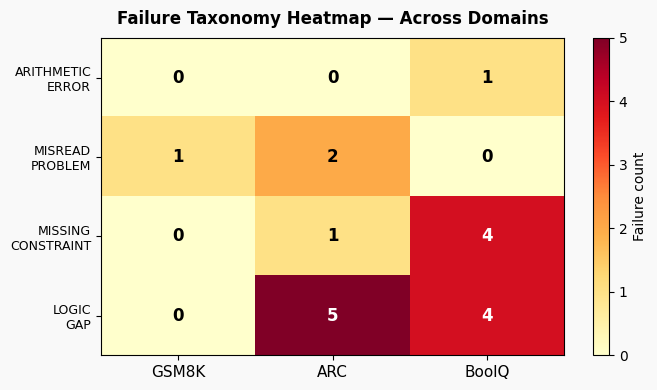

Saved: taxonomy_heatmap.png


In [18]:
# ═══════════════════════════════════════════════════
# CELL 6 — Failure taxonomy heatmap
# ═══════════════════════════════════════════════════
FAILURE_TYPES = ["ARITHMETIC_ERROR", "MISREAD_PROBLEM",
                 "MISSING_CONSTRAINT", "LOGIC_GAP"]

def get_taxonomy(df):
    counts = defaultdict(int)
    for row in df["failure_types"]:
        if row and row != "NONE":
            for ft in row.split("|"):
                ft = ft.strip()
                if ft in FAILURE_TYPES:
                    counts[ft] += 1
    return counts

tax = {
    "GSM8K": get_taxonomy(gsm),
    "ARC":   get_taxonomy(arc),
    "BoolQ": get_taxonomy(boolq),
}

heat_data = np.array([
    [tax[d].get(ft, 0) for d in ["GSM8K", "ARC", "BoolQ"]]
    for ft in FAILURE_TYPES
])

fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor("#f9f9f9")
im = ax.imshow(heat_data, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(3)); ax.set_xticklabels(["GSM8K", "ARC", "BoolQ"], fontsize=11)
ax.set_yticks(range(4)); ax.set_yticklabels(
    ["ARITHMETIC\nERROR", "MISREAD\nPROBLEM", "MISSING\nCONSTRAINT", "LOGIC\nGAP"],
    fontsize=9)

for i in range(4):
    for j in range(3):
        ax.text(j, i, str(heat_data[i, j]),
                ha="center", va="center",
                color="black" if heat_data[i,j] < heat_data.max()*0.6 else "white",
                fontsize=12, fontweight="bold")

plt.colorbar(im, ax=ax, label="Failure count")
ax.set_title("Failure Taxonomy Heatmap — Across Domains",
             fontsize=12, fontweight="bold", pad=10)
fig.tight_layout()
plt.savefig("taxonomy_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: taxonomy_heatmap.png")

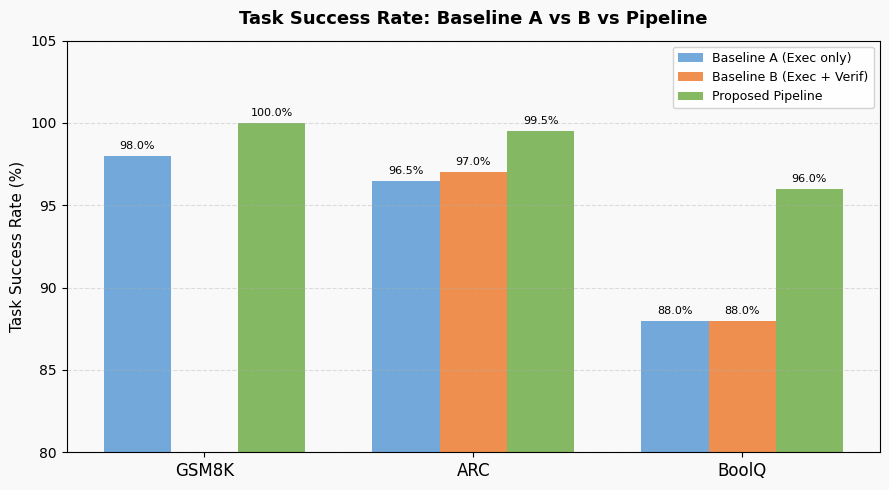

Saved: tsr_comparison.png


In [19]:
 # ═══════════════════════════════════════════════════
# CELL 7 — TSR comparison bar chart
# ═══════════════════════════════════════════════════
domains = ["GSM8K", "ARC", "BoolQ"]
base_a  = [metrics[d]["baseline_a_tsr"] * 100 for d in domains]
base_b  = [metrics[d]["baseline_b_tsr"] * 100
           if metrics[d]["baseline_b_tsr"] is not None else 0
           for d in domains]
pipeline = [metrics[d]["pipeline_tsr"] * 100 for d in domains]

x = np.arange(len(domains))
w = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#f9f9f9")
ax.set_facecolor("#f9f9f9")
ax.grid(axis="y", linestyle="--", alpha=0.4)

b1 = ax.bar(x - w,   base_a,   w, label="Baseline A (Exec only)",       color="#5b9bd5", alpha=0.85)
b2 = ax.bar(x,       base_b,   w, label="Baseline B (Exec + Verif)",     color="#ed7d31", alpha=0.85)
b3 = ax.bar(x + w,   pipeline, w, label="Proposed Pipeline",             color="#70ad47", alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                    f"{h:.1f}%", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(domains, fontsize=12)
ax.set_ylabel("Task Success Rate (%)", fontsize=11)
ax.set_ylim(80, 105)
ax.set_title("Task Success Rate: Baseline A vs B vs Pipeline",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=9, framealpha=0.85)
fig.tight_layout()
plt.savefig("tsr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: tsr_comparison.png")

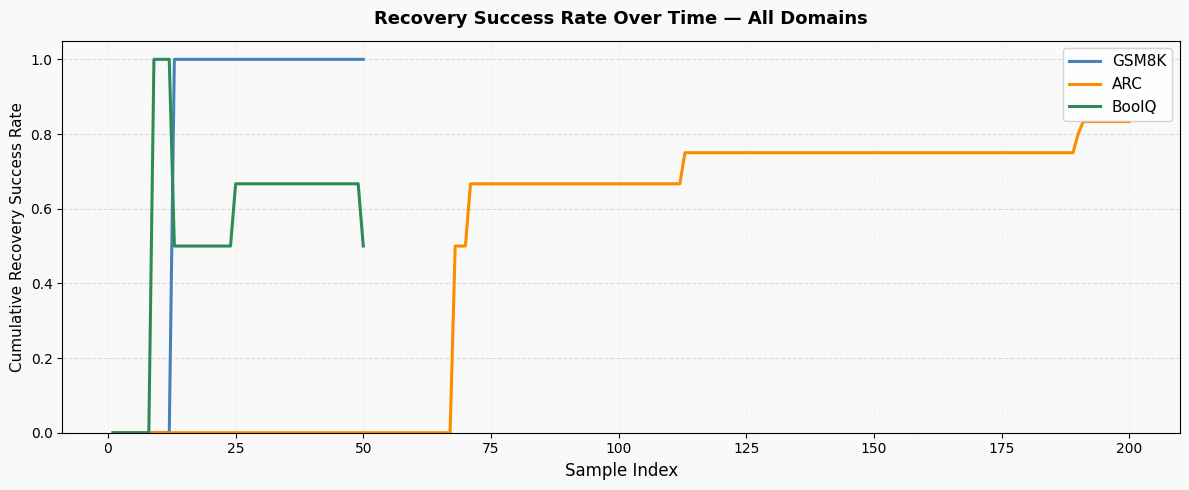

Saved: rsr_combined.png


In [20]:
# ═══════════════════════════════════════════════════
# CELL 8 — Combined RSR over time (all 3 datasets)
# ═══════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#f9f9f9")
ax.set_facecolor("#f9f9f9")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.grid(axis="x", linestyle=":",  alpha=0.2)

colors = {"GSM8K": "steelblue", "ARC": "darkorange", "BoolQ": "seagreen"}
rsr_dfs = {"GSM8K": gsm_rsr, "ARC": arc_rsr, "BoolQ": boolq_rsr}

for domain, rdf in rsr_dfs.items():
    xs  = rdf["sample"].tolist()
    rsr = rdf["rsr"].tolist()
    ax.plot(xs, rsr, color=colors[domain], linewidth=2.2, label=domain)

ax.set_xlabel("Sample Index", fontsize=12)
ax.set_ylabel("Cumulative Recovery Success Rate", fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title("Recovery Success Rate Over Time — All Domains",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=11, framealpha=0.85)
fig.tight_layout()
plt.savefig("rsr_combined.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rsr_combined.png")

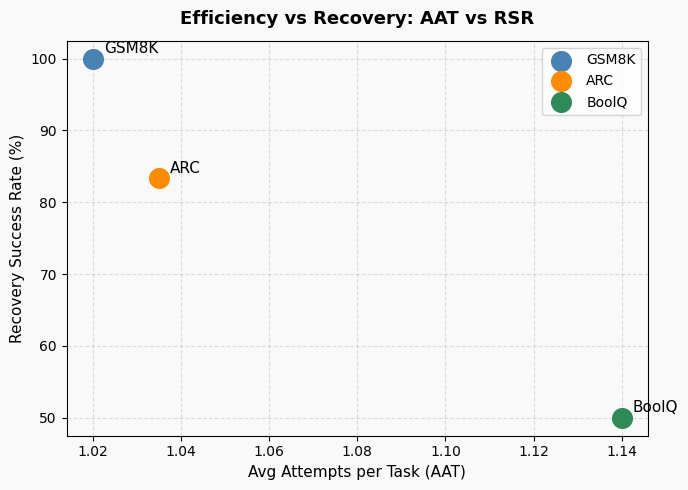

Saved: aat_vs_rsr.png

✅ All analysis complete. Files saved:
  taxonomy_heatmap.png
  tsr_comparison.png
  rsr_combined.png
  aat_vs_rsr.png


In [12]:
# ═══════════════════════════════════════════════════
# CELL 9 — AAT + RSR scatter (efficiency vs accuracy)
# ═══════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("#f9f9f9")
ax.set_facecolor("#f9f9f9")
ax.grid(linestyle="--", alpha=0.4)

for domain in domains:
    m = metrics[domain]
    ax.scatter(m["aat"], m["rsr"] * 100,
               s=200, color=colors[domain],
               zorder=5, label=domain)
    ax.annotate(domain,
                (m["aat"], m["rsr"] * 100),
                textcoords="offset points",
                xytext=(8, 4), fontsize=11)

ax.set_xlabel("Avg Attempts per Task (AAT)", fontsize=11)
ax.set_ylabel("Recovery Success Rate (%)", fontsize=11)
ax.set_title("Efficiency vs Recovery: AAT vs RSR",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=10)
fig.tight_layout()
plt.savefig("aat_vs_rsr.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: aat_vs_rsr.png")

print("\n✅ All analysis complete. Files saved:")
print("  taxonomy_heatmap.png")
print("  tsr_comparison.png")
print("  rsr_combined.png")
print("  aat_vs_rsr.png")